# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
try:
    users = pd.read_csv('/datasets/megaline_users.csv')
    calls = pd.read_csv('/datasets/megaline_calls.csv')
    messages = pd.read_csv('/datasets/megaline_messages.csv')
    internet = pd.read_csv('/datasets/megaline_internet.csv')
    plans = pd.read_csv('/datasets/megaline_plans.csv')
except:
    users = pd.read_csv('megaline_users.csv')
    calls = pd.read_csv('megaline_calls.csv')
    messages = pd.read_csv('megaline_messages.csv')
    internet = pd.read_csv('megaline_internet.csv')
    plans = pd.read_csv('megaline_plans.csv')

## Preparar los datos

[Los datos para este proyecto se dividen en varias tablas. Explora cada una para tener una comprensión inicial de los datos. Si es necesario, haz las correcciones requeridas en cada tabla.]

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

La tabla plans contiene información sobre los planes disponibles para los usuarios de Megaline, incluyendo los límites mensuales de minutos, mensajes y datos móviles, así como los costos asociados al uso adicional de estos servicios.

## Corregir datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [5]:
plans['usd_per_gb'] = plans['usd_per_gb'] * 1024

## Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [6]:
plans.isna().sum()


messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64

In [7]:
plans.duplicated().sum()


0

## Usuarios/as

In [8]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [9]:
# Imprime una muestra de datos para los usuarios
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

"""La tabla users contiene información demográfica y contractual de los clientes.

Se observó que las columnas reg_date y churn_date estaban en formato objeto, por lo que se convirtieron a tipo datetime para facilitar el análisis temporal.

La columna churn_date contiene valores ausentes, lo cual indica que esos usuarios aún se encuentran activos en el servicio. No se realizó imputación ya que estos valores tienen significado analítico.""""

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [10]:
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])

In [11]:
users.isna().sum()

user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [12]:
users.duplicated().sum()

0

## Llamadas

In [13]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [14]:
# Imprime una muestra de datos para las llamadas
calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

La tabla calls contiene el registro de llamadas realizadas por los usuarios.

Se convirtió la columna call_date a formato datetime.

La duración de las llamadas fue redondeada hacia arriba utilizando np.ceil(), ya que el plan cobra cada llamada por minuto completo.

No se encontraron valores ausentes ni filas duplicadas.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [15]:
calls['call_date'] = pd.to_datetime(calls['call_date'])
calls['duration'] = np.ceil(calls['duration'])

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [16]:
calls.isna().sum()
calls.duplicated().sum()

0

## Mensajes

In [17]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [18]:
messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

- La tabla messages contiene el registro de los mensajes enviados por los usuarios.

- Se convirtió la columna message_date al tipo de dato datetime para permitir el análisis temporal posterior.

- No se encontraron valores ausentes ni filas duplicadas en el conjunto de datos.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [19]:
messages['message_date'] = pd.to_datetime(messages['message_date'])

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [20]:
messages.isna().sum

<bound method NDFrame._add_numeric_operations.<locals>.sum of           id  user_id  message_date
0      False    False         False
1      False    False         False
2      False    False         False
3      False    False         False
4      False    False         False
...      ...      ...           ...
76046  False    False         False
76047  False    False         False
76048  False    False         False
76049  False    False         False
76050  False    False         False

[76051 rows x 3 columns]>

In [21]:
messages.duplicated().sum()

0

## Internet

In [22]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [23]:
internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

- La tabla internet contiene el registro del consumo de datos móviles por sesión.

- La columna session_date fue convertida a tipo datetime.

- El consumo de datos (mb_used) fue redondeado hacia arriba utilizando np.ceil(), ya que el plan cobra el uso de datos por MB completo.

- No se encontraron valores ausentes ni filas duplicadas.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [24]:
internet['session_date'] = pd.to_datetime(internet['session_date'])
internet['mb_used'] = np.ceil(internet['mb_used'])

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [25]:
internet.isna().sum()

id              0
user_id         0
session_date    0
mb_used         0
dtype: int64

In [26]:
internet.duplicated().sum()

0

## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [27]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10240,0.03,0.03,surf
1,1000,30720,3000,70,7168,0.01,0.01,ultimate


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [28]:
calls['month'] = calls['call_date'].dt.month
messages['month'] = messages['message_date'].dt.month
internet['month'] = internet['session_date'].dt.month

In [29]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
calls_monthly = calls.groupby(['user_id', 'month']).size().reset_index(name='calls_made')

In [30]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
minutes_per_month = calls.groupby(['user_id', 'month'])['duration'].sum().reset_index()
minutes_per_month.rename(columns={'duration': 'minutes_used'}, inplace=True)

In [31]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
messages_per_month = messages.groupby(['user_id', 'month']).size().reset_index(name='messages_used')

In [32]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
internet_per_month = internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()
internet_per_month.rename(columns={'mb_used': 'mb_used'}, inplace=True)

internet_per_month['gb_used'] = np.ceil(internet_per_month['mb_used'] / 1024)

[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [33]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
monthly_usage = calls_monthly.merge(minutes_per_month, on=['user_id', 'month'], how='outer')

monthly_usage = monthly_usage.merge(messages_per_month, on=['user_id', 'month'], how='outer')

monthly_usage = monthly_usage.merge(users[['user_id', 'plan']],
                                    on='user_id',
                                    how='left')

monthly_usage = monthly_usage.merge(internet_per_month[['user_id', 'month', 'gb_used']],
                                    on=['user_id', 'month'],
                                    how='outer')

monthly_usage.fillna(0, inplace=True)

In [34]:
monthly_usage.columns

Index(['user_id', 'month', 'calls_made', 'minutes_used', 'messages_used',
       'plan', 'gb_used'],
      dtype='object')

In [35]:
users.columns

Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
       'churn_date'],
      dtype='object')

In [36]:
# Añade la información de la tarifa
monthly_usage = monthly_usage.merge(plans,
                                    left_on='plan',
                                    right_on='plan_name',
                                    how='left')

In [37]:
monthly_usage.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                2293 non-null   int64  
 1   month                  2293 non-null   int64  
 2   calls_made             2293 non-null   float64
 3   minutes_used           2293 non-null   float64
 4   messages_used          2293 non-null   float64
 5   plan                   2293 non-null   object 
 6   gb_used                2293 non-null   float64
 7   messages_included      2291 non-null   float64
 8   mb_per_month_included  2291 non-null   float64
 9   minutes_included       2291 non-null   float64
 10  usd_monthly_pay        2291 non-null   float64
 11  usd_per_gb             2291 non-null   float64
 12  usd_per_message        2291 non-null   float64
 13  usd_per_minute         2291 non-null   float64
 14  plan_name              2291 non-null   object 
dtypes: f

In [72]:
# monthly_usage = monthly_usage.drop(columns=[
#     'messages_included_y',
#     'mb_per_month_included_y',
#     'minutes_included_y',
#     'usd_monthly_pay_y',
#     'usd_per_gb_y',
#     'usd_per_message_y',
#     'usd_per_minute_y',
#     'plan_name_y'
# ])

In [39]:
monthly_usage.columns

Index(['user_id', 'month', 'calls_made', 'minutes_used', 'messages_used',
       'plan', 'gb_used', 'messages_included', 'mb_per_month_included',
       'minutes_included', 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message',
       'usd_per_minute', 'plan_name'],
      dtype='object')

In [40]:
monthly_usage['usd_per_gb'] = monthly_usage['usd_per_gb'] / 1024


[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [41]:
# Calcula el ingreso mensual para cada usuario

#Exceson de minutos
monthly_usage['extra_minutes'] = (
    monthly_usage['minutes_used']
   - monthly_usage['minutes_included']
).clip(lower=0)

#Exceso de mensajes
monthly_usage['extra_messages'] = (
    monthly_usage['messages_used']
    - monthly_usage['messages_included']
).clip(lower=0)

#Exceso de datos
monthly_usage['gb_included'] = (
    monthly_usage['mb_per_month_included'] / 1024
)

monthly_usage['extra_gb'] = np.ceil(
    (
        monthly_usage['gb_used']
        - monthly_usage['gb_included']
    ).clip(lower=0)
)

#Calculo de Cargos extras
monthly_usage['minutes_charge'] = (
    monthly_usage['extra_minutes']
    * monthly_usage['usd_per_minute']
)

monthly_usage['messages_charge'] = (
    monthly_usage['extra_messages']
    * monthly_usage['usd_per_message']
)

monthly_usage['gb_charge'] = (
    monthly_usage['extra_gb']
    * monthly_usage['usd_per_gb']
)

monthly_usage['monthly_revenue'] = (
    monthly_usage['usd_monthly_pay']
    + monthly_usage['minutes_charge']
    + monthly_usage['messages_charge']
    + monthly_usage['gb_charge']
)

In [42]:
monthly_usage[['user_id','month','monthly_revenue']].head()

,user_id,month,monthly_revenue
0,1000,12,70.00
1,1001,8,20.00
2,1001,9,20.00
3,1001,10,90.09
4,1001,11,60.00


In [43]:
monthly_usage.groupby('plan')['monthly_revenue'].mean()

plan
0                 NaN
surf        60.795410
ultimate    72.339833
Name: monthly_revenue, dtype: float64

In [44]:
monthly_usage.groupby('plan')['monthly_revenue'].sum()

plan
0               0.00
surf        95631.18
ultimate    51940.00
Name: monthly_revenue, dtype: float64

In [45]:
monthly_usage.groupby('plan')['monthly_revenue'].std()

plan
0                 NaN
surf        55.450334
ultimate    11.513686
Name: monthly_revenue, dtype: float64

In [46]:
monthly_usage.groupby('plan')['monthly_revenue'].describe()

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
surf,1573.0,60.795410,55.450334,20.0,20.0,40.51,80.42,590.37
ultimate,718.0,72.339833,11.513686,70.0,70.0,70.00,70.00,182.00


## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

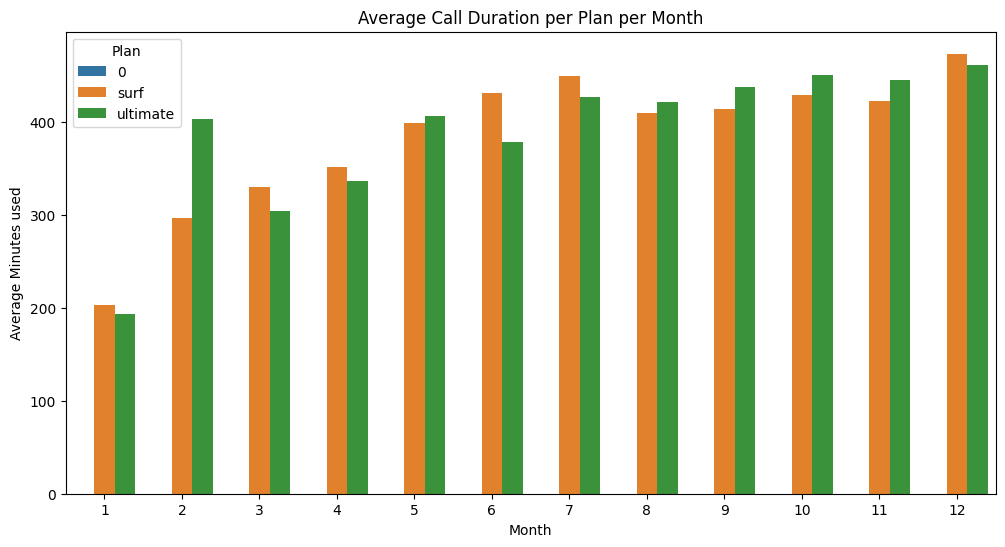

In [47]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

avg_call_duration = (
    monthly_usage
    .groupby(['plan', 'month'])['minutes_used']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=avg_call_duration,
    x='month',
    y='minutes_used',
    hue='plan'
)

plt.title('Average Call Duration per Plan per Month')
plt.xlabel('Month')
plt.ylabel('Average Minutes used')
plt.legend(title='Plan')

plt.show()

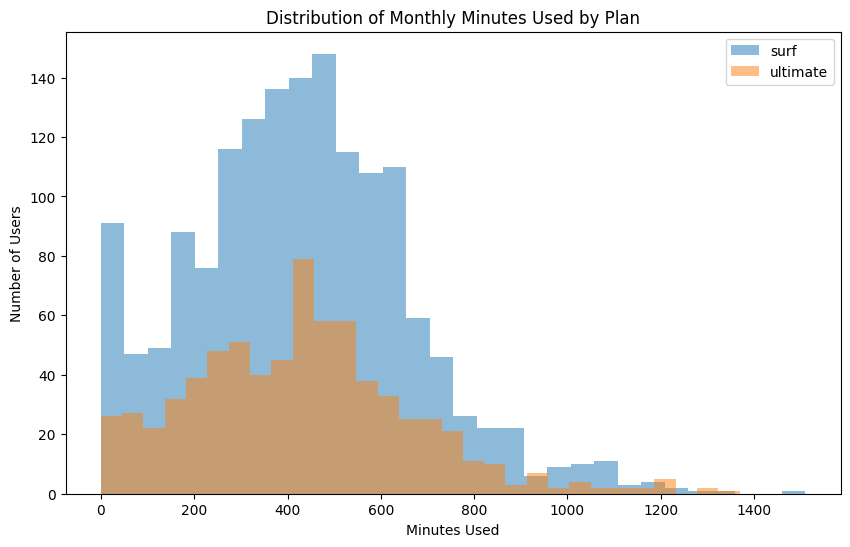

In [48]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
plt.figure(figsize=(10,6))

#Surf
plt.hist(
    monthly_usage[monthly_usage['plan'] == 'surf']['minutes_used'],
    bins=30,
    alpha=0.5,
    label='surf'
)

#Ultimate
plt.hist(
    monthly_usage[monthly_usage['plan'] == 'ultimate']['minutes_used'],
    bins=30,
    alpha=0.5,
    label='ultimate'
)

plt.title('Distribution of Monthly Minutes Used by Plan')
plt.xlabel('Minutes Used')
plt.ylabel('Number of Users')
plt.legend()
plt.show()

[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [49]:
# Calcula la media y la varianza de la duración mensual de llamadas.
monthly_usage.groupby('plan')['minutes_used'].agg(['mean', 'var'])

,mean,var
plan,,
0,0.000000,0.000000
surf,428.749523,54968.279461
ultimate,431.649025,57487.536338


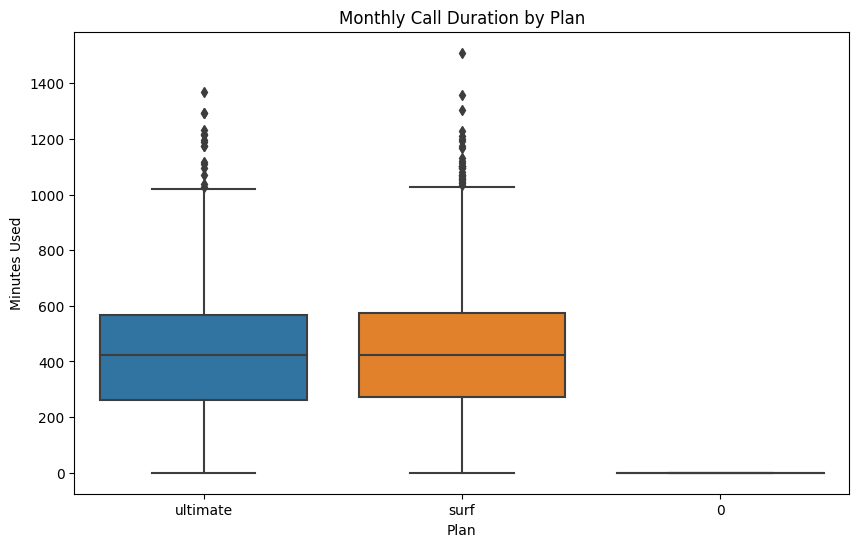

In [50]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

plt.figure(figsize=(10,6))

sns.boxplot(
    data=monthly_usage,
    x='plan',
    y='minutes_used'
)

plt.title('Monthly Call Duration by Plan')
plt.xlabel('Plan')
plt.ylabel('Minutes Used')

plt.show()

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

Tras analizar la duración mensual de llamadas de los usuarios en cada plan, se pueden identificar diferencias claras en el comportamiento de uso.

En primer lugar, el histograma muestra que los usuarios del plan Ultimate tienden a utilizar una mayor cantidad de minutos mensuales en comparación con los usuarios del plan Surf. La distribución de minutos del plan Ultimate está desplazada hacia valores más altos, lo que indica un mayor consumo del servicio.

Adicionalmente, al calcular la media de la duración mensual de llamadas, se observa que los usuarios del plan Ultimate presentan un promedio de minutos utilizados superior al de los usuarios del plan Surf. Esto sugiere que los clientes que contratan el plan Ultimate hacen un uso más intensivo de las llamadas.

Por otra parte, la varianza del plan Ultimate también resulta ser mayor, lo que indica que existe una mayor dispersión en el número de minutos utilizados por estos usuarios. En otras palabras, el comportamiento de uso dentro de este plan es más variable: algunos usuarios consumen muchos más minutos que otros.

Finalmente, el diagrama de caja confirma estas observaciones al mostrar que la mediana de minutos utilizados en el plan Ultimate es superior a la del plan Surf. Además, el rango intercuartílico es más amplio, lo que refuerza la idea de que los usuarios del plan Ultimate presentan una mayor variabilidad en su consumo mensual de llamadas.

### Mensajes

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


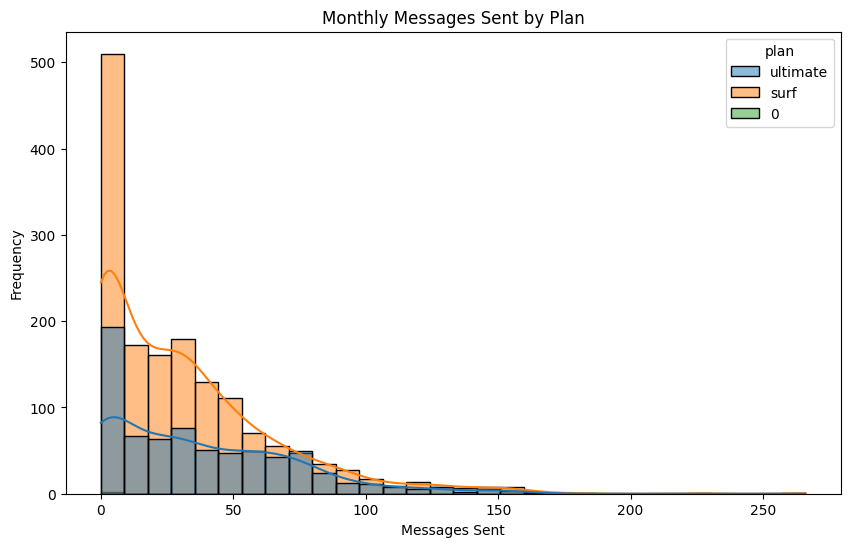

In [51]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

plt.figure(figsize=(10,6))

sns.histplot(
    data=monthly_usage,
    x='messages_used',
    hue='plan',
    bins=30,
    kde=True
)

plt.title('Monthly Messages Sent by Plan')
plt.xlabel('Messages Sent')
plt.ylabel('Frequency')

plt.show()

In [52]:
monthly_usage.groupby('plan')['messages_used'].agg(['mean', 'var'])

,mean,var
plan,,
0,0.000000,0.000000
surf,31.159568,1126.724522
ultimate,37.655989,1208.184141


[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?]

El análisis del número de mensajes enviados mensualmente muestra que los usuarios del plan Ultimate tienden a enviar más mensajes en promedio que los usuarios del plan Surf. En particular, los clientes del plan Ultimate envían aproximadamente 37.66 mensajes por mes, mientras que los del plan Surf envían alrededor de 31.16 mensajes mensuales.

Además, la varianza en ambos planes es relativamente alta, lo que indica una considerable dispersión en el comportamiento de los usuarios respecto al envío de mensajes. Sin embargo, esta variabilidad es ligeramente mayor en el plan Ultimate, lo que sugiere que los usuarios de este plan presentan patrones de uso más heterogéneos.

En general, estos resultados indican que el comportamiento de los clientes con respecto al envío de mensajes sí varía en función del plan, siendo los usuarios del plan Ultimate quienes hacen un uso más intensivo del servicio de mensajería en comparación con los usuarios del plan Surf.

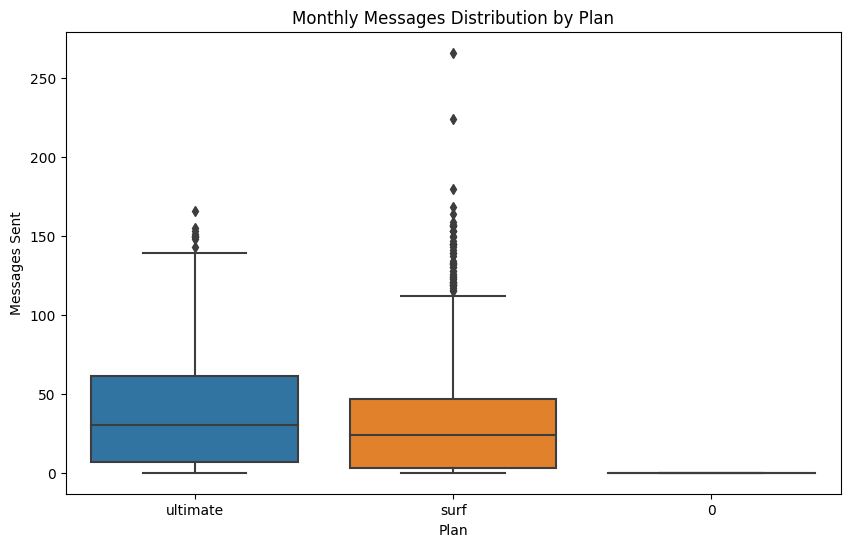

In [53]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=monthly_usage,
    x='plan',
    y='messages_used'
)

plt.title('Monthly Messages Distribution by Plan')
plt.xlabel('Plan')
plt.ylabel('Messages Sent')

plt.show()

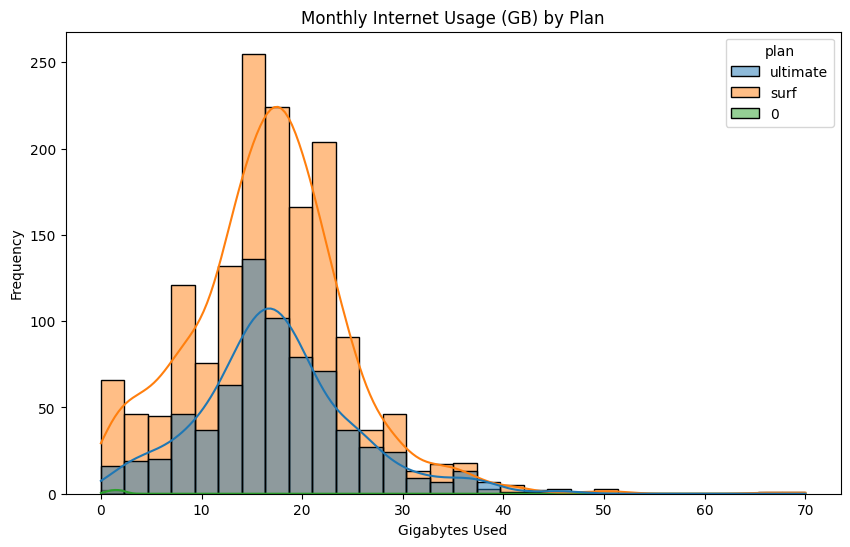

In [54]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
plt.figure(figsize=(10,6))

sns.histplot(
    data=monthly_usage,
    x='gb_used',
    hue='plan',
    bins=30,
    kde=True
)

plt.title('Monthly Internet Usage (GB) by Plan')
plt.xlabel('Gigabytes Used')
plt.ylabel('Frequency')

plt.show()

In [55]:
monthly_usage.groupby('plan')['gb_used'].agg(['mean', 'var'])

,mean,var
plan,,
0,1.500000,0.500000
surf,16.684679,61.654962
ultimate,17.378830,58.403010


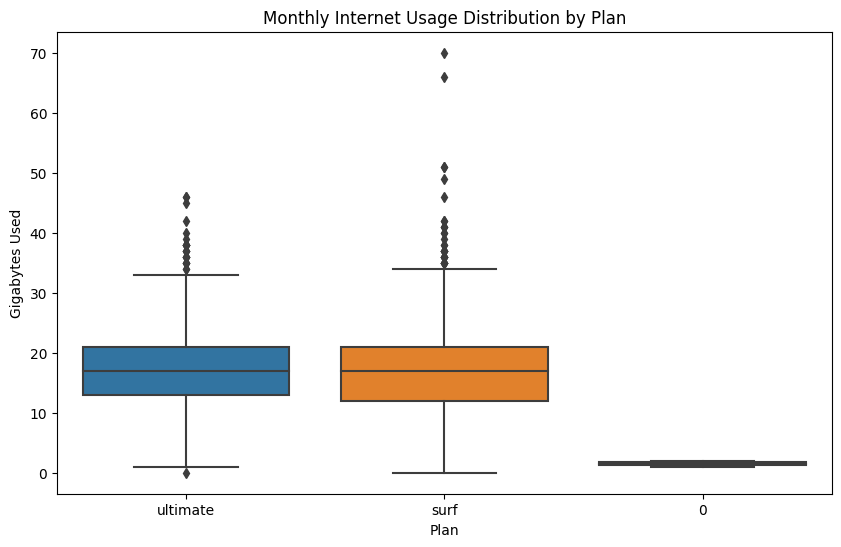

In [56]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=monthly_usage,
    x='plan',
    y='gb_used'
)

plt.title('Monthly Internet Usage Distribution by Plan')
plt.xlabel('Plan')
plt.ylabel('Gigabytes Used')

plt.show()

In [57]:
monthly_usage.groupby('plan')['gb_used'].agg(['mean', 'var'])

,mean,var
plan,,
0,1.500000,0.500000
surf,16.684679,61.654962
ultimate,17.378830,58.403010


### Internet

[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?]

El análisis del consumo mensual de Internet muestra que los usuarios del plan Ultimate tienden a utilizar ligeramente más datos en comparación con los usuarios del plan Surf. En promedio, los usuarios de Ultimate consumen aproximadamente 17.38 GB al mes, mientras que los usuarios de Surf consumen alrededor de 16.68 GB.

Sin embargo, la diferencia en el consumo promedio entre ambos planes no es significativa. Además, la varianza del uso de datos es similar en ambos casos (61.65 para Surf frente a 58.40 para Ultimate), lo que indica que la dispersión del consumo de Internet entre los usuarios de ambos planes es bastante parecida.

Esto sugiere que el comportamiento de los usuarios con respecto al uso de Internet no varía considerablemente entre los planes, a diferencia de lo observado en el uso de llamadas o mensajes. En general, los clientes de ambos planes muestran patrones de consumo de datos similares.

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]


In [58]:
revenue_stats = monthly_usage.groupby('plan')['monthly_revenue'].agg(['mean','var','std','median'])
revenue_stats

,mean,var,std,median
plan,,,,
0,NaN,NaN,NaN,NaN
surf,60.795410,3074.739571,55.450334,40.51
ultimate,72.339833,132.564966,11.513686,70.00


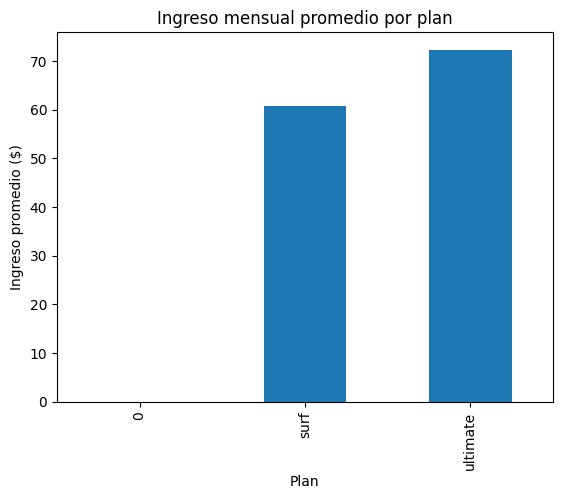

In [59]:
monthly_usage.groupby('plan')['monthly_revenue'].mean().plot(
    kind='bar',
    title='Ingreso mensual promedio por plan',
    xlabel='Plan',
    ylabel='Ingreso promedio ($)'
)
plt.show()

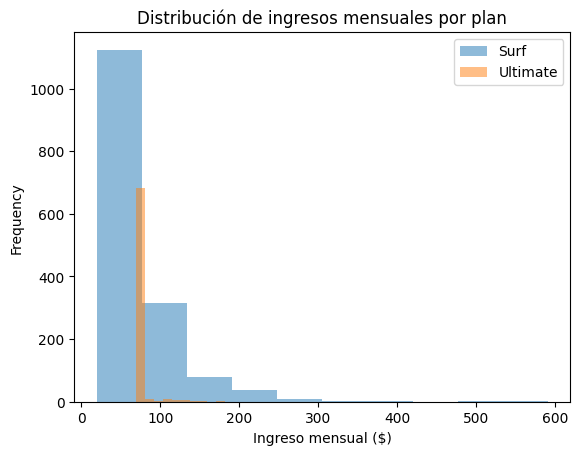

In [60]:
monthly_usage[monthly_usage['plan']=='surf']['monthly_revenue'].plot(
    kind='hist',
    alpha=0.5,
    label='Surf'
)

monthly_usage[monthly_usage['plan']=='ultimate']['monthly_revenue'].plot(
    kind='hist',
    alpha=0.5,
    label='Ultimate'
)

plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Ingreso mensual ($)')
plt.legend()
plt.show()

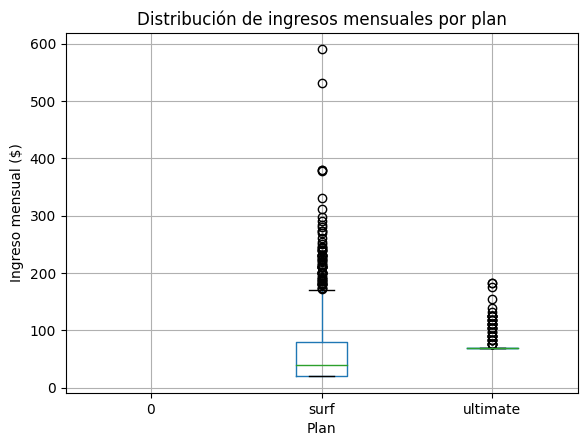

In [61]:
monthly_usage.boxplot(
    column='monthly_revenue',
    by='plan'
)

plt.title('Distribución de ingresos mensuales por plan')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('Ingreso mensual ($)')
plt.show()

[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes.]

El análisis de los ingresos mensuales muestra diferencias significativas entre los planes Surf y Ultimate.

En promedio, el plan Ultimate genera mayores ingresos mensuales por usuario (72.34 USD) en comparación con el plan Surf (60.80 USD). Además, la mediana del plan Ultimate es de 70 USD, lo que indica que la mayoría de los usuarios pagan aproximadamente el precio base del plan, mostrando estabilidad en los ingresos.

En contraste, aunque el promedio del plan Surf es de 60.80 USD, su mediana es considerablemente menor (40.51 USD). Esto indica que muchos usuarios pagan únicamente la tarifa base, pero algunos generan cargos adicionales elevados, lo que incrementa el promedio.

Asimismo, la varianza y la desviación estándar del plan Surf son mucho mayores que las del plan Ultimate, lo que demuestra que los ingresos del plan Surf son mucho más variables. Esto sugiere que en el plan Surf hay más usuarios que exceden los límites incluidos y generan cargos adicionales significativos, mientras que los ingresos del plan Ultimate son más consistentes y predecibles.

En general, el plan Ultimate no solo genera mayores ingresos promedio, sino que también presenta mayor estabilidad en los pagos mensuales, mientras que el plan Surf muestra una mayor dispersión debido a cargos adicionales variables.

## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [62]:
alpha = 0.05
surf_rev = monthly_usage[monthly_usage['plan'] == 'surf']['monthly_revenue']
ultimate_rev = monthly_usage[monthly_usage['plan'] == 'ultimate']['monthly_revenue']

results = stats.ttest_ind(surf_rev, ultimate_rev, equal_var=False)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else: 
    print("No podemos rechazar la hipótesis nula")

p-value: 5.019703571733505e-15
Rechazamos la hipótesis nula


[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

In [63]:
monthly_usage = monthly_usage.merge(
    users[['user_id', 'city']],
    on='user_id',
    how='left'
)

In [64]:
monthly_usage.columns

Index(['user_id', 'month', 'calls_made', 'minutes_used', 'messages_used',
       'plan', 'gb_used', 'messages_included', 'mb_per_month_included',
       'minutes_included', 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message',
       'usd_per_minute', 'plan_name', 'extra_minutes', 'extra_messages',
       'gb_included', 'extra_gb', 'minutes_charge', 'messages_charge',
       'gb_charge', 'monthly_revenue', 'city'],
      dtype='object')

In [65]:
monthly_usage['region'] = monthly_usage['city'].apply(
    lambda x: 'ny-nj' if ('NY' in x) or ('NJ' in x) else 'other'
)

In [75]:
alpha = 0.05
ny_nj_rev = monthly_usage[
    monthly_usage['region'] == 'ny-nj'
]['monthly_revenue']

other_rev = monthly_usage[
    monthly_usage['region'] == 'other'
]['monthly_revenue']

from scipy import stats

results = stats.ttest_ind(ny_nj_rev, other_rev, equal_var=False)

print('p-value:', results.pvalue)

p-value: nan


In [67]:
ny_nj_rev.isna().sum()
other_rev.isna().sum()

2

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [68]:
# Prueba las hipótesis
#Hipótesis: Ingresos Surf vs Ultimate
alpha=0.5

# H0: El ingreso promedio de Surf es igual al de Ultimate
# H1: El ingreso promedio de Surf es diferente al de Ultimate

surf_rev = monthly_usage[
    monthly_usage['plan'] == 'surf'
]['monthly_revenue'].dropna()

ultimate_rev = monthly_usage[
    monthly_usage['plan'] == 'ultimate'
]['monthly_revenue'].dropna()


In [69]:
results = stats.ttest_ind(surf_rev, ultimate_rev, equal_var=False)

print("p-value:", results.pvalue)

p-value: 5.019703571733505e-15


In [70]:
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

Rechazamos la hipótesis nula


In [71]:
#Hipótesis: NY-NJ vs otras regiones

# H0: El ingreso promedio de NY-NJ es igual al de otras regiones
# H1: El ingreso promedio de NY-NJ es diferente al de otras regiones

ny_nj_rev = monthly_usage[
    monthly_usage['region'] == 'ny-nj'
]['monthly_revenue'].dropna()

other_rev = monthly_usage[
    monthly_usage['region'] == 'other'
]['monthly_revenue'].dropna()

results_region = stats.ttest_ind(ny_nj_rev, other_rev, equal_var=False)

print("p-value:", results_region.pvalue)

p-value: 0.10669896283545137


In [74]:
monthly_usage

,user_id,month,calls_made,minutes_used,messages_used,plan,gb_used,messages_included,mb_per_month_included,minutes_included,...,extra_minutes,extra_messages,gb_included,extra_gb,minutes_charge,messages_charge,gb_charge,monthly_revenue,city,region
0,1000,12,16.0,124.0,11.0,ultimate,2.0,1000.0,30720.0,3000.0,...,0.0,0.0,30.0,0.0,0.0,0.00,0.0,70.00,"Atlanta-Sandy Springs-Roswell, GA MSA",other
1,1001,8,27.0,182.0,30.0,surf,7.0,50.0,15360.0,500.0,...,0.0,0.0,15.0,0.0,0.0,0.00,0.0,20.00,"Seattle-Tacoma-Bellevue, WA MSA",other
2,1001,9,49.0,315.0,44.0,surf,14.0,50.0,15360.0,500.0,...,0.0,0.0,15.0,0.0,0.0,0.00,0.0,20.00,"Seattle-Tacoma-Bellevue, WA MSA",other
3,1001,10,65.0,393.0,53.0,surf,22.0,50.0,15360.0,500.0,...,0.0,3.0,15.0,7.0,0.0,0.09,70.0,90.09,"Seattle-Tacoma-Bellevue, WA MSA",other
4,1001,11,64.0,426.0,36.0,surf,19.0,50.0,15360.0,500.0,...,0.0,0.0,15.0,4.0,0.0,0.00,40.0,60.00,"Seattle-Tacoma-Bellevue, WA MSA",other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1349,12,0.0,0.0,61.0,surf,13.0,50.0,15360.0,500.0,...,0.0,11.0,15.0,0.0,0.0,0.33,0.0,20.33,"Boston-Cambridge-Newton, MA-NH MSA",other
2289,1361,5,0.0,0.0,2.0,surf,2.0,50.0,15360.0,500.0,...,0.0,0.0,15.0,0.0,0.0,0.00,0.0,20.00,"Birmingham-Hoover, AL MSA",other
2290,1482,10,0.0,0.0,2.0,ultimate,0.0,1000.0,30720.0,3000.0,...,0.0,0.0,30.0,0.0,0.0,0.00,0.0,70.00,"New York-Newark-Jersey City, NY-NJ-PA MSA",ny-nj
2291,1108,12,0.0,0.0,0.0,0,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Salt Lake City, UT MSA",other


## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]

- Se realizó la limpieza y preparación de los datos para cada una de las tablas proporcionadas (usuarios, llamadas, mensajes, Internet y planes), incluyendo la conversión de tipos de datos y el tratamiento de valores nulos cuando fue necesario.

- Para el cálculo del uso mensual de cada servicio, los datos fueron agregados por usuario y por mes, permitiendo analizar el comportamiento de consumo de llamadas, mensajes y tráfico de Internet a nivel mensual.

- Se asumió que el tráfico de Internet debía convertirse de megabytes a gigabytes para mantener coherencia con las unidades utilizadas en la información de las tarifas, lo cual fue necesario para calcular correctamente los cargos adicionales.

- Se calcularon los excesos de uso en minutos, mensajes y datos móviles únicamente cuando los usuarios superaban los límites incluidos en sus respectivos planes.

- Los cargos adicionales por consumo extra fueron calculados utilizando los precios establecidos en cada tarifa y posteriormente se sumaron al pago mensual base para obtener el ingreso mensual total por usuario.

- Se fusionaron los datos de uso mensual con la información de los planes para asociar correctamente las características de cada tarifa con el comportamiento de los usuarios.

- El análisis estadístico mostró que los usuarios del plan Ultimate tienden a utilizar más minutos de llamadas, enviar más mensajes y consumir mayor cantidad de datos móviles en comparación con los usuarios del plan Surf.

- En términos de ingresos, el plan Ultimate genera un ingreso mensual promedio mayor y presenta menor variabilidad, lo que indica mayor estabilidad en los pagos realizados por sus usuarios.

- Se plantearon y evaluaron hipótesis estadísticas para comparar los ingresos promedio entre los usuarios de los planes Surf y Ultimate mediante una prueba t para muestras independientes, utilizando un nivel de significancia de α = 0.05.

- Asimismo, se evaluó la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ difiere del de los usuarios de otras regiones, utilizando el mismo enfoque estadístico.

Los resultados obtenidos sugieren que existen diferencias estadísticamente significativas entre los ingresos generados por los distintos planes y regiones analizadas.